In [1]:
!pip install xgboost lightgbm shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
import lightgbm as lgb
import shap

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Libraries installed and data loaded successfully!")

Libraries installed and data loaded successfully!


In [2]:
# Initialize and train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")

XGBoost Test Accuracy: 0.9561


In [3]:
# Initialize and train LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# Predict and evaluate
lgb_preds = lgb_model.predict(X_test)
lgb_acc = accuracy_score(y_test, lgb_preds)
print(f"LightGBM Test Accuracy: {lgb_acc:.4f}")

LightGBM Test Accuracy: 0.9649


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Generating SHAP Summary Plot...


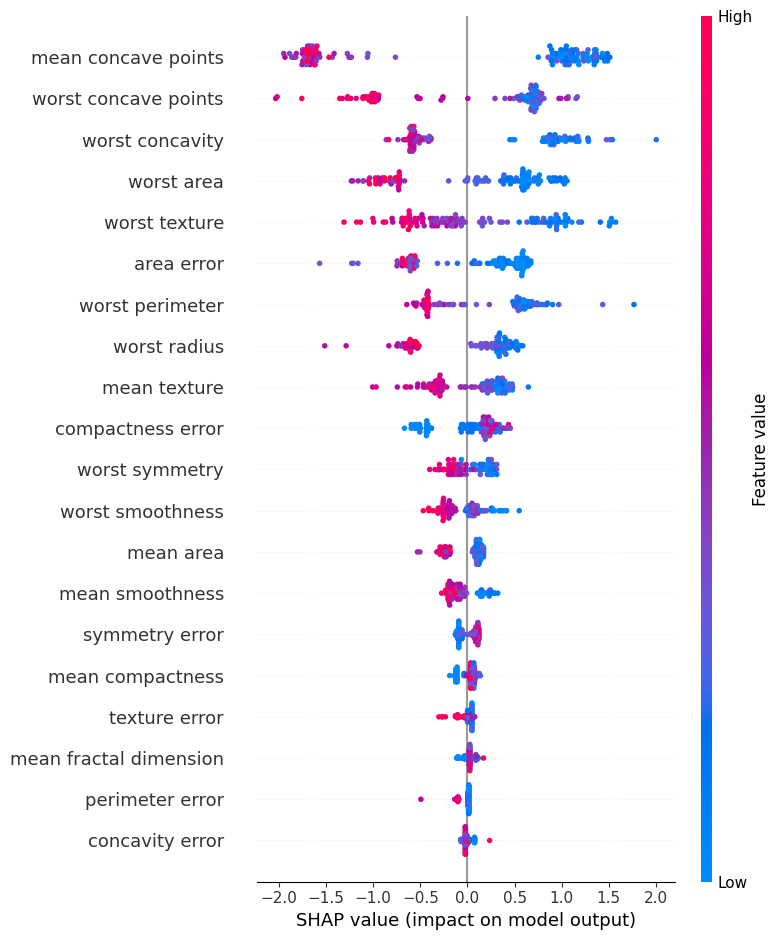

In [4]:
# Create a SHAP Tree Explainer for the XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot summary of feature importances
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test, feature_names=feature_names)